## Data を読み込んでみよう

In [56]:
# Data を読み込んでみる
import pandas as pd

df_info = pd.read_csv('MathProgramming/Chapter1/accomodation_info.csv', index_col=0, parse_dates=[0])
df_info

,顧客ID,宿泊者名,プラン,金額
日時,,,,
2018-11-01 00:02:21,110034,若松 花子,B,19000
2018-11-01 00:03:10,112804,津田 美加子,D,20000
2018-11-01 00:06:19,110275,吉本 美加子,D,20000
2018-11-01 00:08:41,110169,坂本 直人,B,19000
2018-11-01 00:12:22,111504,青山 零,A,15000
...,...,...,...,...
2020-10-31 23:38:51,110049,吉本 篤司,A,3000
2020-10-31 23:42:12,110127,喜嶋 浩,A,3000
2020-10-31 23:47:24,115464,藤本 明美,D,8000


#### 宿泊料金
曜日や季節によって変動する場合があり、特にコロナウイルス感染症の流行後は大幅な値下げを行なっている。
#### 宿泊 Plan
A: 素泊まり
B: 朝夕食付き
C: 素泊まり露天風呂付客室
D: 朝夕食付き露天風呂付客室

## 時系列 Data を可視化してみよう

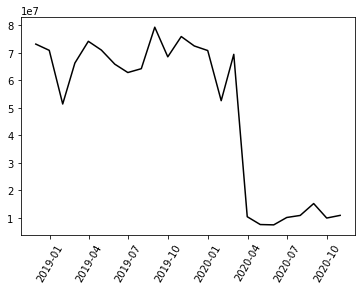

In [57]:
# 時系列 Data を可視化してみる
import matplotlib.pyplot as plt

# 月ごとの売上
plt.plot(df_info['金額'].resample('M').sum(), color='k')
plt.xticks(rotation=60)
plt.show()

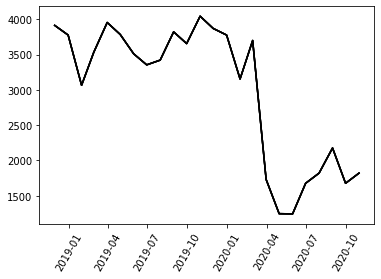

In [58]:
# 月ごとの利用者数
plt.plot(df_info.resample('M').count(), color='k')
plt.xticks(rotation=60)
plt.show()

売上も利用者（宿泊者）も、感染症流行を経て激減していることがわかる。

## 平均値、中央値、最小値、最大値を出力してみよう

In [59]:
# 平均値、中央値、最小値、最大値を出力
x_mean = df_info['顧客ID'].value_counts().mean()
x_median = df_info['顧客ID'].value_counts().median()
x_min = df_info['顧客ID'].value_counts().min()
x_max = df_info['顧客ID'].value_counts().max()
print('平均値:', x_mean)
print('中央値:', x_median)
print('最小値:', x_min)
print('最大値:', x_max)

平均値: 13.073641997812613
中央値: 7.0
最小値: 1
最大値: 184


- **平均値が13回なのに対して中央値が７回と値がズレている。**
利用者の利用回数が一様に分布していれば平均値と中央値は概ね一致するが、利用回数が少ない人が多く、利用回数が多い人がまばらに分布していると分布に偏りが見られる場合、平均値と中央値にズレが生じているのではないかと考えることができる。

- **最小値が１なのに対し最大値が184、最小値が13に近い値なのに対して最大値は184と、平均値から遠い位置にある**
最小値に近いところに利用回数が集中していて、最大値に近いところはまだらに点在しているのではないかと予想できる

## 分布の形を見てみよう

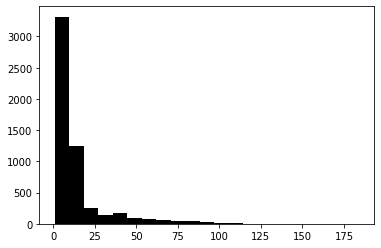

In [60]:
x = df_info['顧客ID'].value_counts()
x_hist, t_hist, _ = plt.hist(x, 21, color='k')
plt.show()

左端に Data が集中している様子が確認とれる。
ほとんどの利用者がごく少数の利用のみで０付近に週通するが、少数だけ極めて多い回数の利用者が存在し、平均値が最小値側に大幅に偏っていた理由だったことがわかる。

現在、分析している Data がどのような数式に基づく分布に従うか Histogram上に「**近似曲線**」を引くことで、実際にべき分布をしている、ということを説得力高く示す。

## 分布の近似曲線を求めてみよう

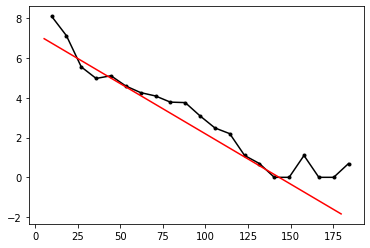

In [61]:
# 近似曲線の Parameter を算出する
import numpy as np

# Params 設定
epsilon = 1
num = 15

# 変数設定
weight = x_hist[1:num]
t = np.zeros(len(t_hist) - 1)
for i in range(len(t_hist) - 1):
    t[i] = (t_hist[i] + t_hist[i + 1]) / 2

# Fitting（最小二乗近似）による Parameter の算出
a, b = np.polyfit(t[1:num], np.log(x_hist[1:num]), 1)

# Fitting曲線（直線）の描画
xt = np.zeros(len(t))
for i in range(len(t)):
    xt[i] = a * t[i] + b

plt.plot(t_hist[1:], np.log(x_hist + epsilon), marker='.', color='k')
plt.plot(t, xt, color='r')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

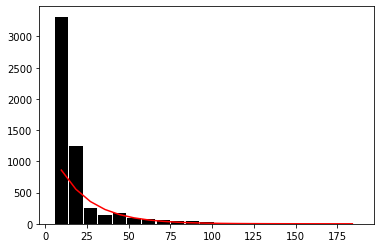

In [62]:
# 近似曲線を描く
import math

t = t_hist[1:]
xt = np.zeros(len(t))
for i in range(len(t)):
    xt[i] = math.exp(a * t[i] + b)

plt.bar(t_hist[1:], x_hist, width=8, color='k')
plt.plot(t, xt, color='r')
plt.show

近似曲線を描く場合は、
- なぜその曲線を描いたのか
- どのように描いたのか
- その曲線によってどのような意味を伝えたいのか

ということが重要。

描いた近似曲線を自分自身で理解していなと
- Data に対する誤った理解
- 顧客への誤った理解の報告 = 信用の失墜

に繋がってしまう。

## Plan ごとに Data を抽出してみよう

In [63]:
# プラン毎に Data を抽出してみる
df_info[df_info["プラン"]=='A']

,顧客ID,宿泊者名,プラン,金額
日時,,,,
2018-11-01 00:12:22,111504,青山 零,A,15000
2018-11-01 00:18:26,114882,山岸 淳,A,15000
2018-11-01 00:20:47,110865,石田 和也,A,15000
2018-11-01 00:21:52,110069,山岸 聡太郎,A,15000
2018-11-01 15:02:07,111430,山田 明美,A,15000
...,...,...,...,...
2020-10-31 22:14:38,110004,山岸 健一,A,3000
2020-10-31 23:38:51,110049,吉本 篤司,A,3000
2020-10-31 23:42:12,110127,喜嶋 浩,A,3000


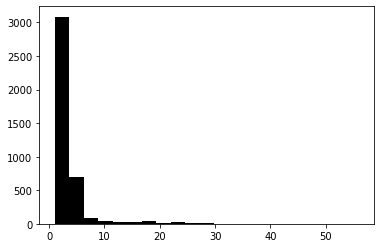

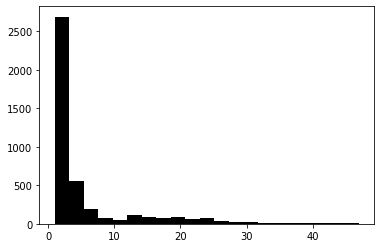

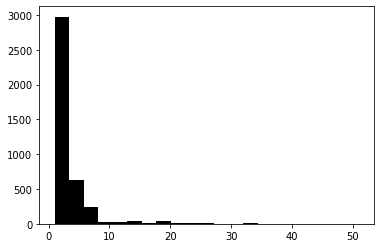

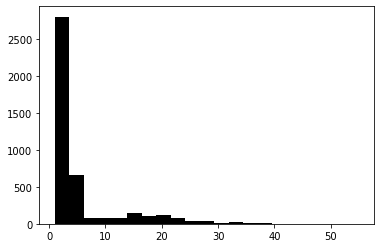

In [64]:
# プラン毎の Histogram を表示する
plans = ['A', 'B', 'C', 'D']

for plan in plans:
    df_plan = df_info[df_info["プラン"] == plan]
    x_plan = df_plan['顧客ID'].value_counts()
    xplan_hist, tplan_hist, _ = plt.hist(x_plan, 21, color='k')
    plt.show()

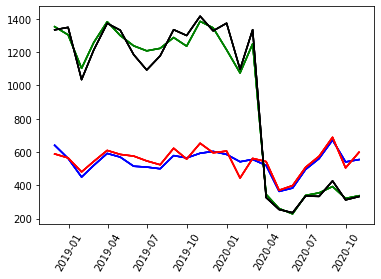

In [65]:
# プランごとの毎月の利用者数を表示する
colors = ['b', 'g', 'r', 'k']
for p, c in zip(plans, colors):
    plt.plot(df_info[df_info['プラン']==p].resample('M').count(), color=c)

plt.xticks(rotation=60)
plt.show()

- Plan B or D（ともに朝夕食付き）については、感染症の流行を強く受けている
- Plan A or C（ともに朝夕食なし）については、感染症の流行の影響はほとんど受けていない。

ということが確認とれる。

#### 導かれる予想:
宿泊客は感染症の影響で Restaurant などの密室をなるべく避けるようになったものの、Remote work を行なう新規顧客の獲得などによって、朝夕食のない Plan についてはその影響を最小限にとどめられたのではないか。」

## 大口顧客の行動を分析してみよう
**Micro な分析を行なっていく際に重要なこと:**
少ない数ではあるが極めて利用頻度（宿泊頻度）が高い「大口顧客」の分析になる。


In [66]:
# 利用頻度の上位10名の情報を出力する
for i_rank in range(10):
    id = df_info['顧客ID'].value_counts().index[i_rank]
    print(df_info[df_info['顧客ID']==id])

                       顧客ID   宿泊者名 プラン     金額
日時                                           
2018-11-03 19:03:50  110067  石田 知実   B  19000
2018-11-03 23:35:27  110067  石田 知実   B  19000
2018-11-07 19:15:07  110067  石田 知実   D  20000
2018-11-14 23:01:12  110067  石田 知実   B  19000
2018-11-20 17:58:54  110067  石田 知実   D  20000
...                     ...    ...  ..    ...
2020-10-19 22:53:41  110067  石田 知実   D   8000
2020-10-22 15:22:04  110067  石田 知実   A   3000
2020-10-22 18:45:23  110067  石田 知実   C   7000
2020-10-22 23:35:10  110067  石田 知実   C   7000
2020-10-31 19:03:46  110067  石田 知実   A   3000

[184 rows x 4 columns]
                       顧客ID    宿泊者名 プラン     金額
日時                                            
2018-11-02 21:26:41  110043  斉藤 あすか   A  15000
2018-11-05 16:32:52  110043  斉藤 あすか   B  19000
2018-11-17 19:46:04  110043  斉藤 あすか   B  19000
2018-11-23 16:11:16  110043  斉藤 あすか   C  19000
2018-11-24 22:38:48  110043  斉藤 あすか   B  19000
...                     ...     ...  ..    ...
20

value_counts()関数から index を取り出すことで、上位１位から順に情報を引き出すことができる。

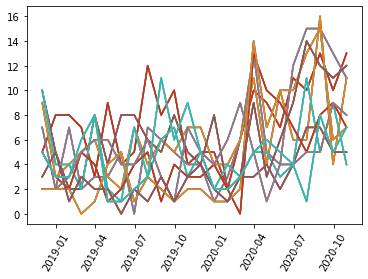

In [67]:
# 利用頻度が1～10位の時系列表示を行なう
for i_rank in range(10):
    id = df_info['顧客ID'].value_counts().index[i_rank]
    plt.plot(df_info[df_info['顧客ID']==id].resample('M').count())
    plt.xticks(rotation=60)

plt.show()

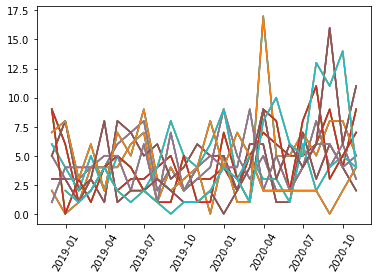

In [68]:
# 利用頻度が11~20位の時系列表示を行なう
for i_rank in range(10, 20):
    id = df_info['顧客ID'].value_counts().index[i_rank]
    plt.plot(df_info[df_info['顧客ID']==id].resample('M').count())
    plt.xticks(rotation=60)
plt.show()

- 上位1~10位の Graph を見ると、感染症流行後にむしろ利用頻度が増加しているものが見受けられる。
- 11~20位の Graph を見ると、一定期間に突出しているものがあるものの、感染症流行前後では横ばいのものも見られる。

感染症流行前後での利用者の動向に特徴が見られそうだと考えられる。

## 感染症流行前後の顧客の行動を分析してみよう
利用頻度の高い大口顧客にある程度的を絞ったうえで、その様子を確認していく。
感染症流行前後を2020年３月１日前後とし、その前後での大口顧客ひとりひとりの累積利用回数を可視化してみる。
（=> 感染症流行前後で Data を分割し、それぞれの累積利用回数を算出する。）

In [69]:
# Index を reset する
# 「日時情報」が Column ではなく Index として指定されているので Column の１つとする（※ 日時に2020年３月１日前後という条件式で比較させる為）
df_info = df_info.reset_index()

In [70]:
# 感染症流行前後の Data を分離（分割）する
import datetime as dt
target_date = dt.datetime(2020, 3,1)
df_info_pre = df_info[df_info['日時'] < target_date]
df_info_post = df_info[df_info['日時'] >= target_date]
print(df_info_pre)

# 分割したそれぞれの Data数と元の Data数が同一であることを確認する
print(df_info_pre.shape[0] + df_info_post.shape[0], df_info.shape[0])

                       日時    顧客ID    宿泊者名 プラン     金額
0     2018-11-01 00:02:21  110034   若松 花子   B  19000
1     2018-11-01 00:03:10  112804  津田 美加子   D  20000
2     2018-11-01 00:06:19  110275  吉本 美加子   D  20000
3     2018-11-01 00:08:41  110169   坂本 直人   B  19000
4     2018-11-01 00:12:22  111504    青山 零   A  15000
...                   ...     ...     ...  ..    ...
58321 2020-02-29 23:49:54  111270  中津川 里佳   C  19000
58322 2020-02-29 23:52:14  112251   田中 真綾   B  19000
58323 2020-02-29 23:52:51  115804   井高 真綾   D  20000
58324 2020-02-29 23:53:09  112928   石田 修平   D  20000
58325 2020-02-29 23:55:28  110504   田辺 京助   B  19000

[58326 rows x 5 columns]
71722 71722


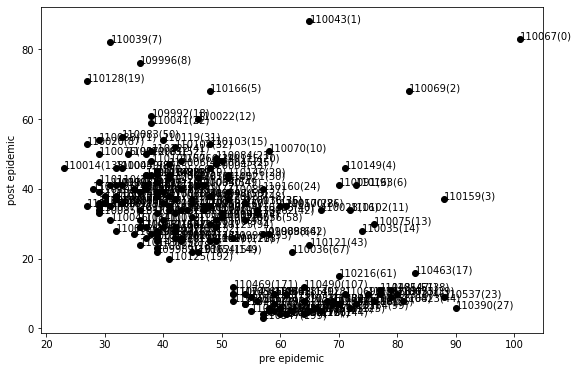

In [71]:
# 感染症流行前後の Data を二次元に Mapping する ①

# 利用回数１位から100位までを対象とし、それらの感染症前と後の利用回数をそれぞれ 100x2次元の配列に格納する
num = 200
count_pre_and_post = np.zeros((num, 2))
for i_rank in range(num):
    id = df_info['顧客ID'].value_counts().index[i_rank]
    count_pre_and_post[i_rank][0] = int(df_info_pre[df_info_pre['顧客ID'] == id].count()[0])
    count_pre_and_post[i_rank][1] = int(df_info_post[df_info_post['顧客ID'] == id].count()[0])

# 100点の２次元 Data を散布図で plot する
plt.figure(figsize=(9, 6))
plt.scatter(count_pre_and_post.T[0], count_pre_and_post.T[1], color='k')

for i_rank in range(num):
    id = df_info['顧客ID'].value_counts().index[i_rank]
    text = f'{str(id)}({str(i_rank)})'
    plt.text(count_pre_and_post[i_rank][0], count_pre_and_post[i_rank][1], text, color='k')

plt.xlabel('pre epidemic')
plt.ylabel('post epidemic')

plt.show()

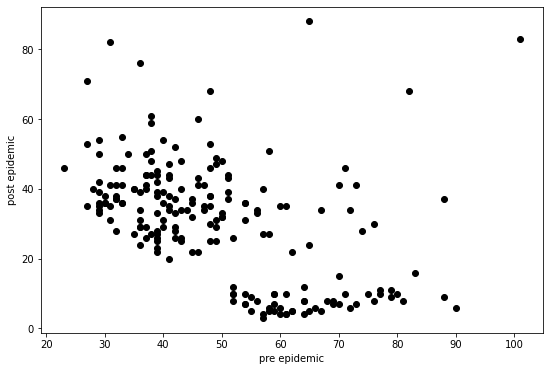

In [72]:
# 感染症流行前後の Data を二次元に Mapping する ②
# (Text を非表示にした散布図)

num = 200
count_pre_and_post = np.zeros((num, 2))
for i_rank in range(num):
    id = df_info['顧客ID'].value_counts().index[i_rank]
    count_pre_and_post[i_rank][0] = int(df_info_pre[df_info_pre['顧客ID'] == id].count()[0])
    count_pre_and_post[i_rank][1] = int(df_info_post[df_info_post['顧客ID'] == id].count()[0])

plt.figure(figsize=(9, 6))
plt.scatter(count_pre_and_post.T[0], count_pre_and_post.T[1], color='k')

# for i_rank in range(num):
#     id = df_info['顧客ID'].value_counts().index[i_rank]
#     text = f'{str(id)}({str(i_rank)})'
#     plt.text(count_pre_and_post[i_rank][0], count_pre_and_post[i_rank][1], text, color='k')

plt.xlabel('pre epidemic')
plt.ylabel('post epidemic')

plt.show()

感染症流行前後であまり傾向の変わらないもの（散布図の中心部付近に位置するもの）も多くあるが、感染症流行前のみ、あるいは後のみに極端に偏ったものもいくつか確認でき、利用者の傾向の違いは大きく見られる。